# 🏦 Loan Approval Prediction
**Alfido Tech Data Science Internship | Task 2**

---
**Objective:** Build a supervised ML pipeline to predict whether a loan application will be approved, handling class imbalance and comparing multiple models.

**Dataset:** [Kaggle — Loan Approval Prediction by Bhanu Pratap Biswas](https://www.kaggle.com/datasets/bhanupratapbiswas/loan-approval-prediction-case-study)

## 📦 Step 1 — Install & Import Libraries

In [25]:
# Uncomment if running on Colab
# !pip install imbalanced-learn -q

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Preprocessing
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer

# Imbalance handling
from imblearn.over_sampling import SMOTE
from imblearn.pipeline import Pipeline as ImbPipeline

# Models
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.svm import SVC

# Evaluation
from sklearn.metrics import (
    classification_report, confusion_matrix, roc_auc_score,
    roc_curve, precision_recall_curve, f1_score,
    precision_score, recall_score, accuracy_score
)

sns.set_theme(style='whitegrid', palette='muted', font_scale=1.05)
plt.rcParams.update({'figure.dpi': 120, 'axes.titleweight': 'bold'})
SEED = 42
print('Libraries loaded ✅')

Libraries loaded ✅


## 📥 Step 2 — Load Dataset
> Upload `loan_data.csv` (or whatever the Kaggle file is named) to Colab.

In [26]:
from google.colab import files
uploaded = files.upload()  # a file picker will appear — select your CSV

import io
filename = list(uploaded.keys())[0]
df = pd.read_csv(io.BytesIO(uploaded[filename]))
print(f'Loaded: {filename}')
print(f'Shape: {df.shape}')
df.head()

Saving loan_prediction.csv to loan_prediction (3).csv
Loaded: loan_prediction (3).csv
Shape: (614, 13)


,Loan_ID,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status
0,LP001002,Male,No,0,Graduate,No,5849,0.0,NaN,360.0,1.0,Urban,Y
1,LP001003,Male,Yes,1,Graduate,No,4583,1508.0,128.0,360.0,1.0,Rural,N
2,LP001005,Male,Yes,0,Graduate,Yes,3000,0.0,66.0,360.0,1.0,Urban,Y
3,LP001006,Male,Yes,0,Not Graduate,No,2583,2358.0,120.0,360.0,1.0,Urban,Y
4,LP001008,Male,No,0,Graduate,No,6000,0.0,141.0,360.0,1.0,Urban,Y


## 🔍 Step 3 — Basic EDA

In [27]:
print('=== Column Info ===')
print(df.dtypes)
print()
print('=== Missing Values ===')
missing = df.isnull().sum()
print(missing[missing > 0])
print()
print('=== Summary Statistics ===')
df.describe(include='all')

=== Column Info ===
Loan_ID               object
Gender                object
Married               object
Dependents            object
Education             object
Self_Employed         object
ApplicantIncome        int64
CoapplicantIncome    float64
LoanAmount           float64
Loan_Amount_Term     float64
Credit_History       float64
Property_Area         object
Loan_Status           object
dtype: object

=== Missing Values ===
Gender              13
Married              3
Dependents          15
Self_Employed       32
LoanAmount          22
Loan_Amount_Term    14
Credit_History      50
dtype: int64

=== Summary Statistics ===


,Loan_ID,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status
count,614,601,611,599,614,582,614.000000,614.000000,592.000000,600.00000,564.000000,614,614
unique,614,2,2,4,2,2,NaN,NaN,NaN,NaN,NaN,3,2
top,LP002990,Male,Yes,0,Graduate,No,NaN,NaN,NaN,NaN,NaN,Semiurban,Y
freq,1,489,398,345,480,500,NaN,NaN,NaN,NaN,NaN,233,422
mean,NaN,NaN,NaN,NaN,NaN,NaN,5403.459283,1621.245798,146.412162,342.00000,0.842199,NaN,NaN
std,NaN,NaN,NaN,NaN,NaN,NaN,6109.041673,2926.248369,85.587325,65.12041,0.364878,NaN,NaN
min,NaN,NaN,NaN,NaN,NaN,NaN,150.000000,0.000000,9.000000,12.00000,0.000000,NaN,NaN
25%,NaN,NaN,NaN,NaN,NaN,NaN,2877.500000,0.000000,100.000000,360.00000,1.000000,NaN,NaN
50%,NaN,NaN,NaN,NaN,NaN,NaN,3812.500000,1188.500000,128.000000,360.00000,1.000000,NaN,NaN
75%,NaN,NaN,NaN,NaN,NaN,NaN,5795.000000,2297.250000,168.000000,360.00000,1.000000,NaN,NaN


In [28]:
# Auto-detect target column
target_candidates = [c for c in df.columns if 'status' in c.lower() or 'approval' in c.lower() or 'loan_status' in c.lower()]
TARGET = target_candidates[0] if target_candidates else df.columns[-1]
print(f'Target column detected: "{TARGET}"')
print()
print('Class distribution:')
print(df[TARGET].value_counts())
print(f'\nImbalance ratio: {df[TARGET].value_counts().iloc[0] / df[TARGET].value_counts().iloc[1]:.2f}:1')

Target column detected: "Loan_Status"

Class distribution:
Loan_Status
Y    422
N    192
Name: count, dtype: int64

Imbalance ratio: 2.20:1


## 📊 Step 4 — Visualisation 1: Class Distribution & Missing Values

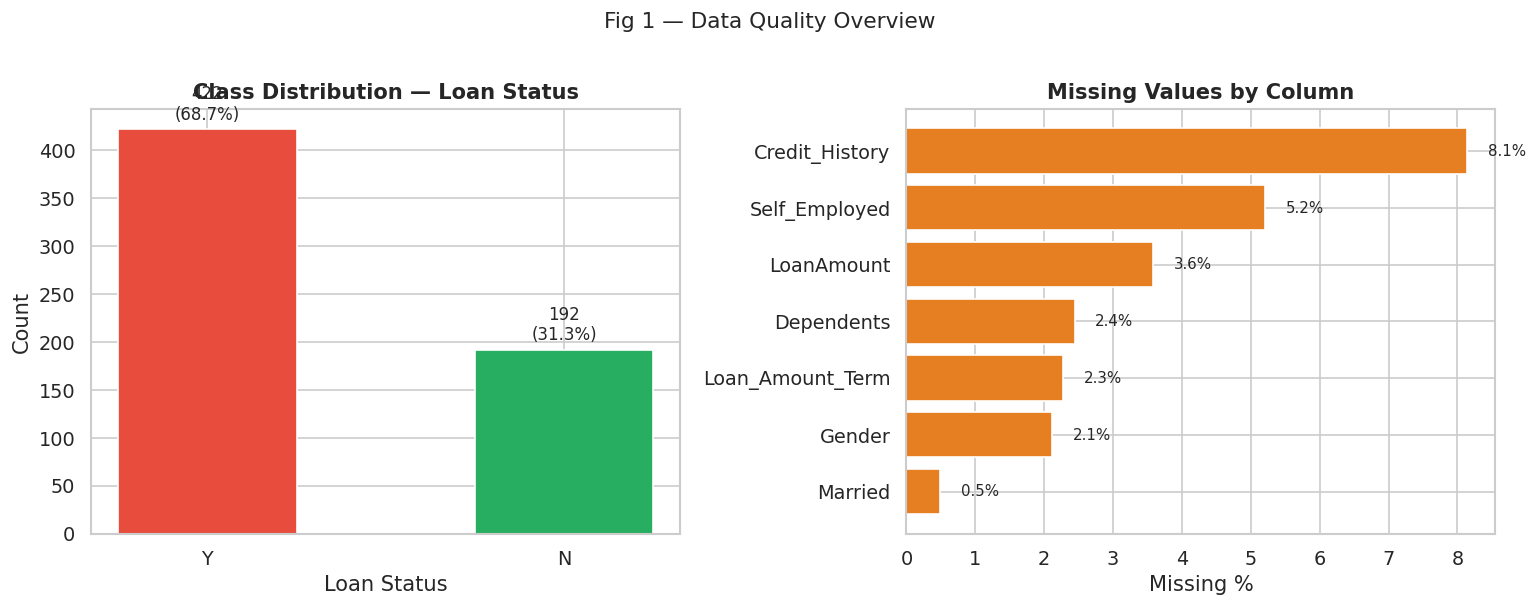

In [29]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Class balance
counts = df[TARGET].value_counts()
colors_bar = ['#E74C3C', '#27AE60']
bars = axes[0].bar(counts.index.astype(str), counts.values, color=colors_bar, edgecolor='white', width=0.5)
for bar, v in zip(bars, counts.values):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 10,
                 f'{v:,}\n({v/len(df)*100:.1f}%)', ha='center', fontsize=10)
axes[0].set_title('Class Distribution — Loan Status')
axes[0].set_xlabel('Loan Status')
axes[0].set_ylabel('Count')

# Missing values
miss = df.isnull().sum().sort_values(ascending=False)
miss = miss[miss > 0]
if len(miss) > 0:
    miss_pct = miss / len(df) * 100
    axes[1].barh(miss.index[::-1], miss_pct.values[::-1], color='#E67E22')
    axes[1].set_xlabel('Missing %')
    axes[1].set_title('Missing Values by Column')
    for i, v in enumerate(miss_pct.values[::-1]):
        axes[1].text(v + 0.3, i, f'{v:.1f}%', va='center', fontsize=9)
else:
    axes[1].text(0.5, 0.5, 'No missing values', ha='center', va='center',
                 transform=axes[1].transAxes, fontsize=13)
    axes[1].set_title('Missing Values')

plt.suptitle('Fig 1 — Data Quality Overview', fontsize=13, y=1.01)
plt.tight_layout()
plt.savefig('fig1_class_dist_missing.png', bbox_inches='tight')
plt.show()

## 📊 Step 5 — Visualisation 2: Feature Distributions by Loan Status

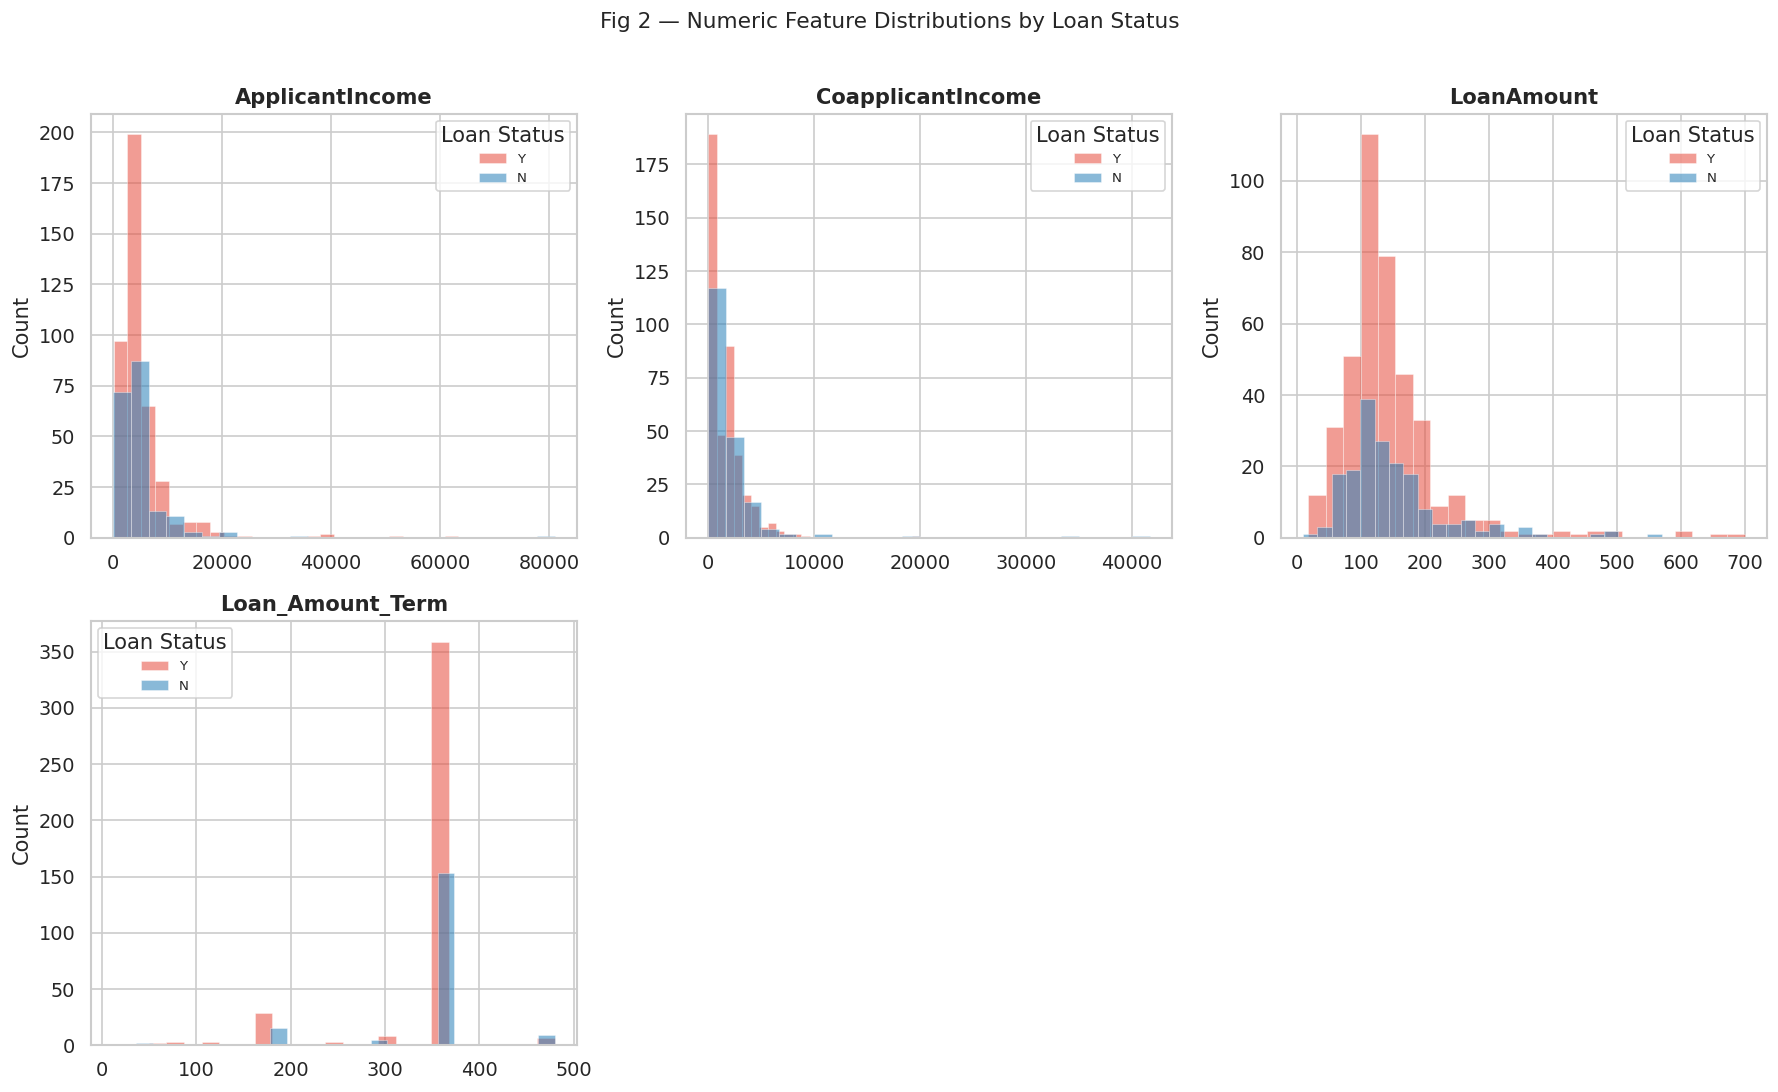

In [30]:
num_cols = df.select_dtypes(include=np.number).columns.tolist()
num_cols = [c for c in num_cols if c != TARGET and df[c].nunique() > 5]
num_cols = num_cols[:6]  # show max 6

n = len(num_cols)
cols_per_row = 3
rows = (n + cols_per_row - 1) // cols_per_row

fig, axes = plt.subplots(rows, cols_per_row, figsize=(15, 4.5 * rows))
axes = np.array(axes).flatten()

for i, col in enumerate(num_cols):
    for label, color in zip(df[TARGET].unique(), ['#E74C3C', '#2980B9']):
        subset = df[df[TARGET] == label][col].dropna()
        axes[i].hist(subset, bins=25, alpha=0.55, color=color,
                     label=str(label), edgecolor='white', linewidth=0.4)
    axes[i].set_title(col)
    axes[i].legend(title='Loan Status', fontsize=8)
    axes[i].set_ylabel('Count')

for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)

plt.suptitle('Fig 2 — Numeric Feature Distributions by Loan Status', fontsize=13, y=1.01)
plt.tight_layout()
plt.savefig('fig2_feature_distributions.png', bbox_inches='tight')
plt.show()

## 📊 Step 6 — Visualisation 3: Categorical Features vs Loan Status

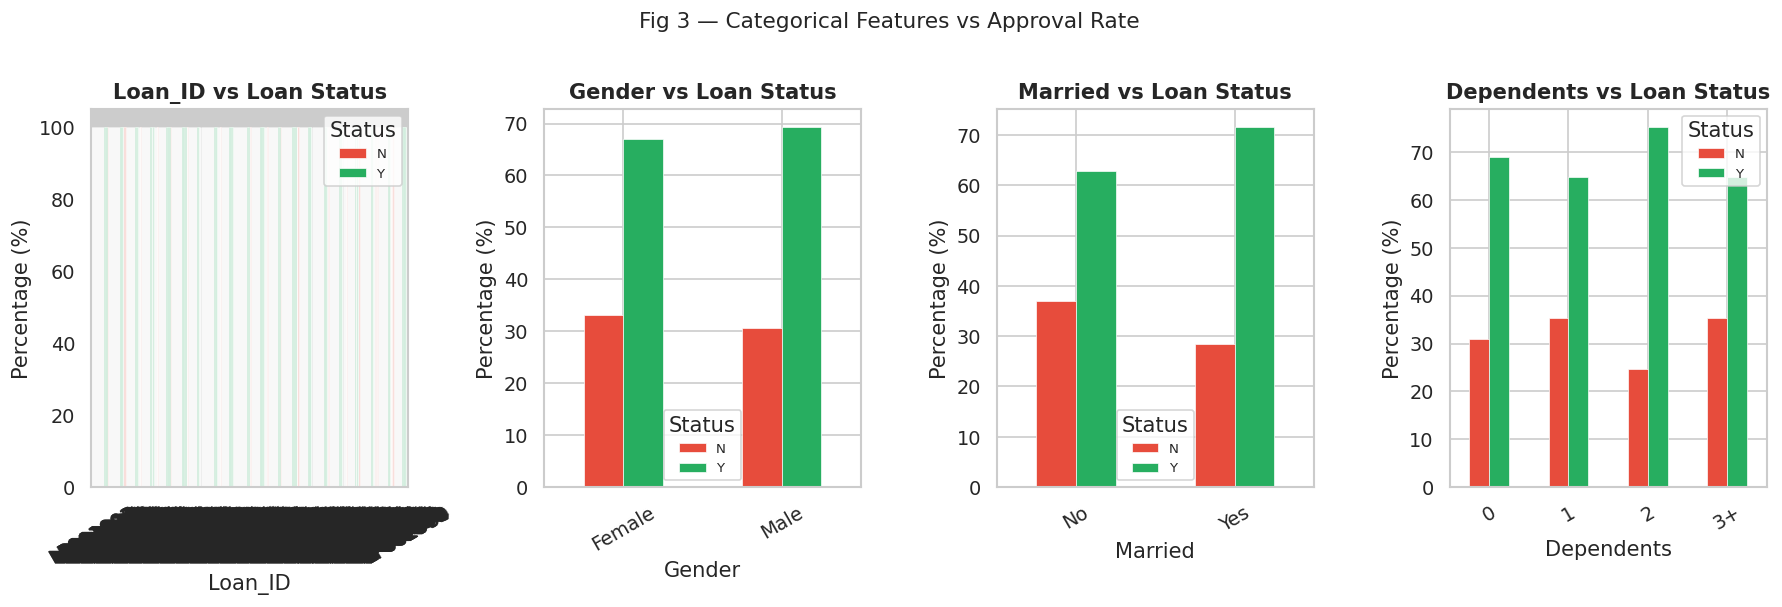

In [31]:
cat_cols = df.select_dtypes(include='object').columns.tolist()
cat_cols = [c for c in cat_cols if c != TARGET][:4]

fig, axes = plt.subplots(1, min(len(cat_cols), 4), figsize=(15, 5))
if len(cat_cols) == 1:
    axes = [axes]
axes = list(axes) if len(cat_cols) > 1 else axes

for i, col in enumerate(cat_cols[:4]):
    ct = pd.crosstab(df[col], df[TARGET], normalize='index') * 100
    ct.plot(kind='bar', ax=axes[i], color=['#E74C3C', '#27AE60'],
            edgecolor='white', linewidth=0.4)
    axes[i].set_title(f'{col} vs Loan Status')
    axes[i].set_ylabel('Percentage (%)')
    axes[i].tick_params(axis='x', rotation=30)
    axes[i].legend(title='Status', fontsize=8)

plt.suptitle('Fig 3 — Categorical Features vs Approval Rate', fontsize=13, y=1.01)
plt.tight_layout()
plt.savefig('fig3_categorical_features.png', bbox_inches='tight')
plt.show()

## 🧹 Step 7 — Preprocessing Pipeline

In [32]:
from sklearn.preprocessing import OrdinalEncoder

# Separate features and target
X = df.drop(columns=[TARGET])

# Encode target
le_target = LabelEncoder()
y = le_target.fit_transform(df[TARGET].astype(str))
print('Target classes:', le_target.classes_)
print('Encoded as:', dict(zip(le_target.classes_, le_target.transform(le_target.classes_))))

# Drop ID-like columns
id_cols = [c for c in X.columns if 'id' in c.lower() or 'loan_id' in c.lower()]
X = X.drop(columns=id_cols, errors='ignore')
print(f'Dropped ID columns: {id_cols}')

# Identify column types
num_features = X.select_dtypes(include=np.number).columns.tolist()
cat_features = X.select_dtypes(include='object').columns.tolist()
print(f'\nNumeric features ({len(num_features)}): {num_features}')
print(f'Categorical features ({len(cat_features)}): {cat_features}')

Target classes: ['N' 'Y']
Encoded as: {'N': np.int64(0), 'Y': np.int64(1)}
Dropped ID columns: ['Loan_ID']

Numeric features (5): ['ApplicantIncome', 'CoapplicantIncome', 'LoanAmount', 'Loan_Amount_Term', 'Credit_History']
Categorical features (6): ['Gender', 'Married', 'Dependents', 'Education', 'Self_Employed', 'Property_Area']


In [33]:
from sklearn.preprocessing import OneHotEncoder

# Build preprocessor
numeric_transformer = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler',  StandardScaler())
])

categorical_transformer = Pipeline([
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('encoder', OneHotEncoder(handle_unknown='ignore', sparse_output=False))
])

preprocessor = ColumnTransformer([
    ('num', numeric_transformer, num_features),
    ('cat', categorical_transformer, cat_features)
])

# Train / test split (stratified)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=SEED, stratify=y
)
print(f'Train size: {len(X_train):,} | Test size: {len(X_test):,}')
print(f'Train class ratio: {np.bincount(y_train)}')
print(f'Test  class ratio: {np.bincount(y_test)}')

Train size: 491 | Test size: 123
Train class ratio: [154 337]
Test  class ratio: [38 85]


## ⚖️ Step 8 — Handle Class Imbalance with SMOTE

Before SMOTE: [154 337]
After  SMOTE: [337 337]


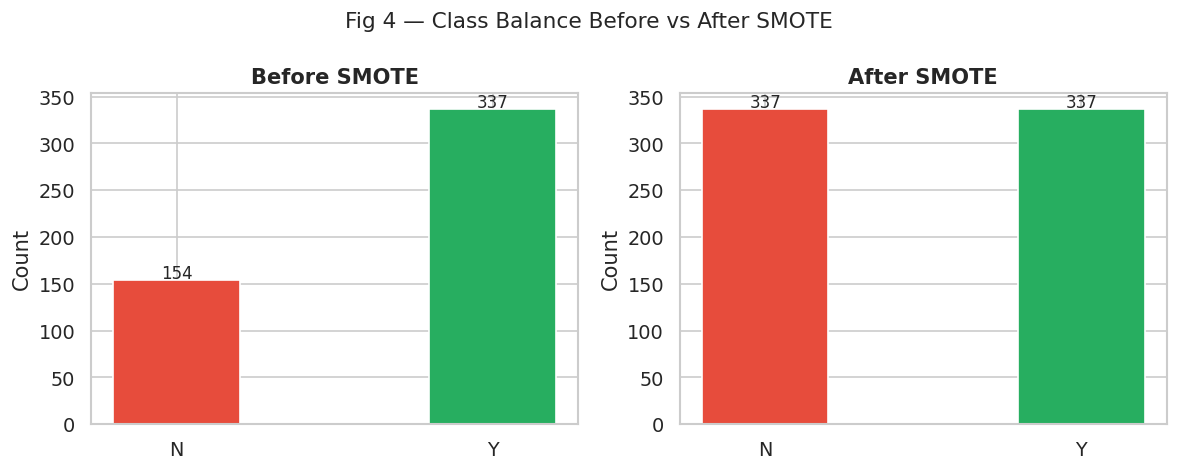

In [34]:
# Preprocess training data first, then apply SMOTE
X_train_prep = preprocessor.fit_transform(X_train)
X_test_prep  = preprocessor.transform(X_test)

smote = SMOTE(random_state=SEED)
X_train_bal, y_train_bal = smote.fit_resample(X_train_prep, y_train)

print('Before SMOTE:', np.bincount(y_train))
print('After  SMOTE:', np.bincount(y_train_bal))

fig, axes = plt.subplots(1, 2, figsize=(10, 4))
for ax, counts, title in zip(
    axes,
    [np.bincount(y_train), np.bincount(y_train_bal)],
    ['Before SMOTE', 'After SMOTE']
):
    labels = le_target.classes_
    ax.bar(labels, counts, color=['#E74C3C', '#27AE60'], edgecolor='white', width=0.4)
    for j, v in enumerate(counts):
        ax.text(j, v + 2, str(v), ha='center', fontsize=10)
    ax.set_title(title)
    ax.set_ylabel('Count')

plt.suptitle('Fig 4 — Class Balance Before vs After SMOTE', fontsize=13)
plt.tight_layout()
plt.savefig('fig4_smote_balance.png', bbox_inches='tight')
plt.show()

## 🤖 Step 9 — Train & Evaluate Multiple Models

In [35]:
models = {
    'Logistic Regression':    LogisticRegression(max_iter=1000, random_state=SEED, class_weight='balanced'),
    'Decision Tree':          DecisionTreeClassifier(max_depth=6, random_state=SEED, class_weight='balanced'),
    'Random Forest':          RandomForestClassifier(n_estimators=150, random_state=SEED, class_weight='balanced', n_jobs=-1),
    'Gradient Boosting':      GradientBoostingClassifier(n_estimators=150, learning_rate=0.1, max_depth=4, random_state=SEED),
}

results = {}

for name, model in models.items():
    model.fit(X_train_bal, y_train_bal)
    y_pred  = model.predict(X_test_prep)
    y_proba = model.predict_proba(X_test_prep)[:, 1] if hasattr(model, 'predict_proba') else None

    results[name] = {
        'model':     model,
        'y_pred':    y_pred,
        'y_proba':   y_proba,
        'accuracy':  accuracy_score(y_test, y_pred),
        'precision': precision_score(y_test, y_pred, zero_division=0),
        'recall':    recall_score(y_test, y_pred, zero_division=0),
        'f1':        f1_score(y_test, y_pred, zero_division=0),
        'roc_auc':   roc_auc_score(y_test, y_proba) if y_proba is not None else None,
    }
    print(f'{name:25s} | Acc: {results[name]["accuracy"]:.3f} | F1: {results[name]["f1"]:.3f} | AUC: {results[name]["roc_auc"]:.3f}')

Logistic Regression       | Acc: 0.821 | F1: 0.872 | AUC: 0.876
Decision Tree             | Acc: 0.732 | F1: 0.807 | AUC: 0.674
Random Forest             | Acc: 0.805 | F1: 0.864 | AUC: 0.788
Gradient Boosting         | Acc: 0.764 | F1: 0.828 | AUC: 0.773


## 📊 Step 10 — Visualisation 5: Model Comparison Bar Chart

                     Accuracy  Precision  Recall  F1-Score  ROC-AUC
Logistic Regression     0.821      0.862   0.882     0.872    0.876
Decision Tree           0.732      0.802   0.812     0.807    0.674
Random Forest           0.805      0.835   0.894     0.864    0.788
Gradient Boosting       0.764      0.833   0.824     0.828    0.773


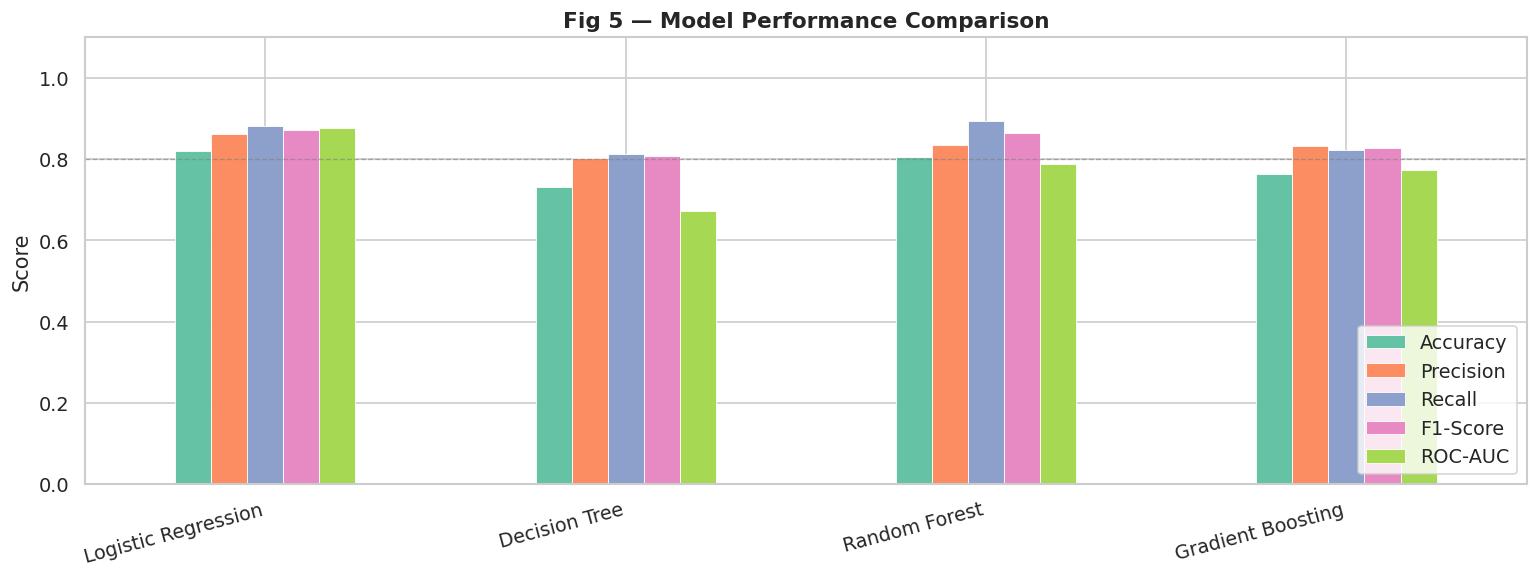

In [36]:
metrics_df = pd.DataFrame({
    name: {
        'Accuracy':  v['accuracy'],
        'Precision': v['precision'],
        'Recall':    v['recall'],
        'F1-Score':  v['f1'],
        'ROC-AUC':   v['roc_auc'] if v['roc_auc'] else 0,
    }
    for name, v in results.items()
}).T

print(metrics_df.round(3).to_string())

ax = metrics_df.plot(kind='bar', figsize=(13, 5), edgecolor='white', linewidth=0.5,
                     color=sns.color_palette('Set2', 5))
ax.set_title('Fig 5 — Model Performance Comparison', fontsize=13)
ax.set_ylabel('Score')
ax.set_xticklabels(metrics_df.index, rotation=15, ha='right')
ax.set_ylim(0, 1.1)
ax.legend(loc='lower right')
ax.axhline(0.8, color='gray', linestyle='--', linewidth=0.8, alpha=0.6)
plt.tight_layout()
plt.savefig('fig5_model_comparison.png', bbox_inches='tight')
plt.show()

## 📊 Step 11 — Visualisation 6: ROC Curves

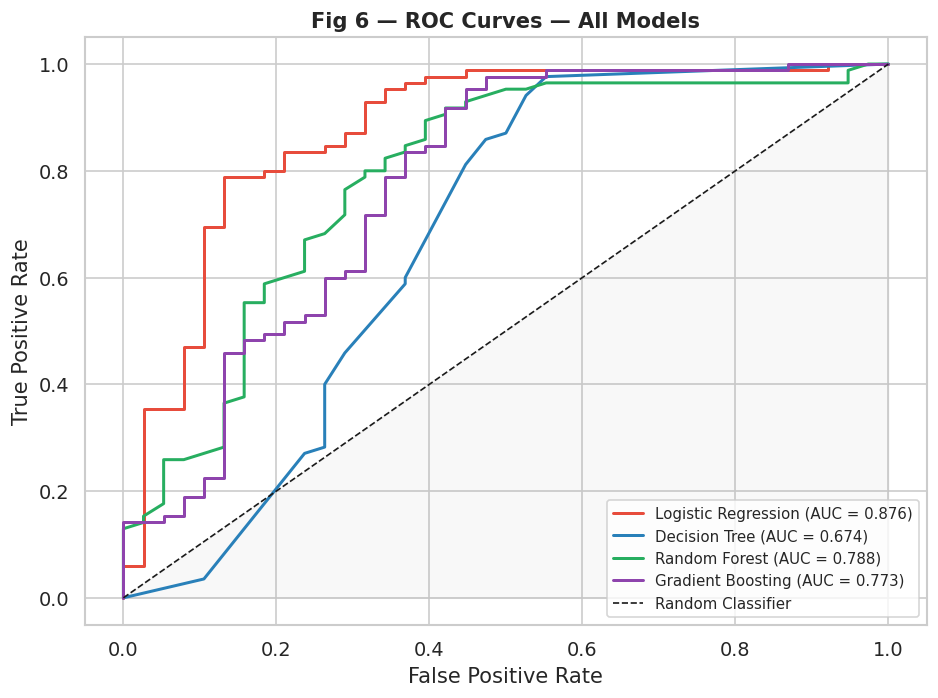

In [37]:
fig, ax = plt.subplots(figsize=(8, 6))
colors_roc = ['#E74C3C', '#2980B9', '#27AE60', '#8E44AD']

for (name, v), color in zip(results.items(), colors_roc):
    if v['y_proba'] is not None:
        fpr, tpr, _ = roc_curve(y_test, v['y_proba'])
        ax.plot(fpr, tpr, color=color, lw=1.8,
                label=f"{name} (AUC = {v['roc_auc']:.3f})")

ax.plot([0, 1], [0, 1], 'k--', linewidth=1, label='Random Classifier')
ax.set_xlabel('False Positive Rate')
ax.set_ylabel('True Positive Rate')
ax.set_title('Fig 6 — ROC Curves — All Models')
ax.legend(loc='lower right', fontsize=9)
ax.fill_between([0, 1], [0, 1], alpha=0.05, color='gray')
plt.tight_layout()
plt.savefig('fig6_roc_curves.png', bbox_inches='tight')
plt.show()

## 📊 Step 12 — Confusion Matrices for All Models

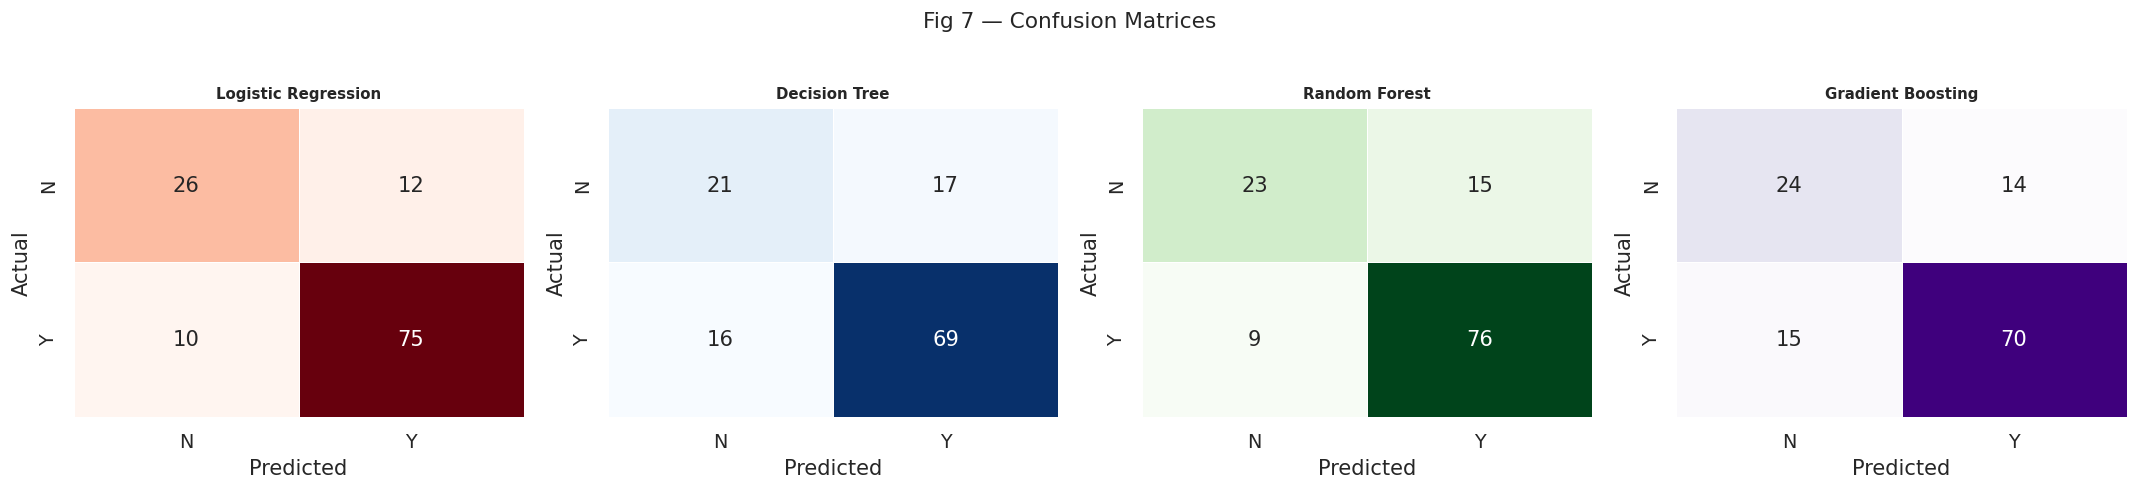

In [38]:
fig, axes = plt.subplots(1, 4, figsize=(18, 4))
cmaps = ['Reds', 'Blues', 'Greens', 'Purples']

for ax, (name, v), cmap in zip(axes, results.items(), cmaps):
    cm = confusion_matrix(y_test, v['y_pred'])
    sns.heatmap(cm, annot=True, fmt='d', cmap=cmap, ax=ax,
                xticklabels=le_target.classes_,
                yticklabels=le_target.classes_,
                linewidths=0.5, cbar=False)
    ax.set_title(name, fontsize=9)
    ax.set_xlabel('Predicted')
    ax.set_ylabel('Actual')

plt.suptitle('Fig 7 — Confusion Matrices', fontsize=13, y=1.02)
plt.tight_layout()
plt.savefig('fig7_confusion_matrices.png', bbox_inches='tight')
plt.show()

## 📊 Step 13 — Feature Importance (Best Model)

Best model: Logistic Regression (AUC = 0.876)


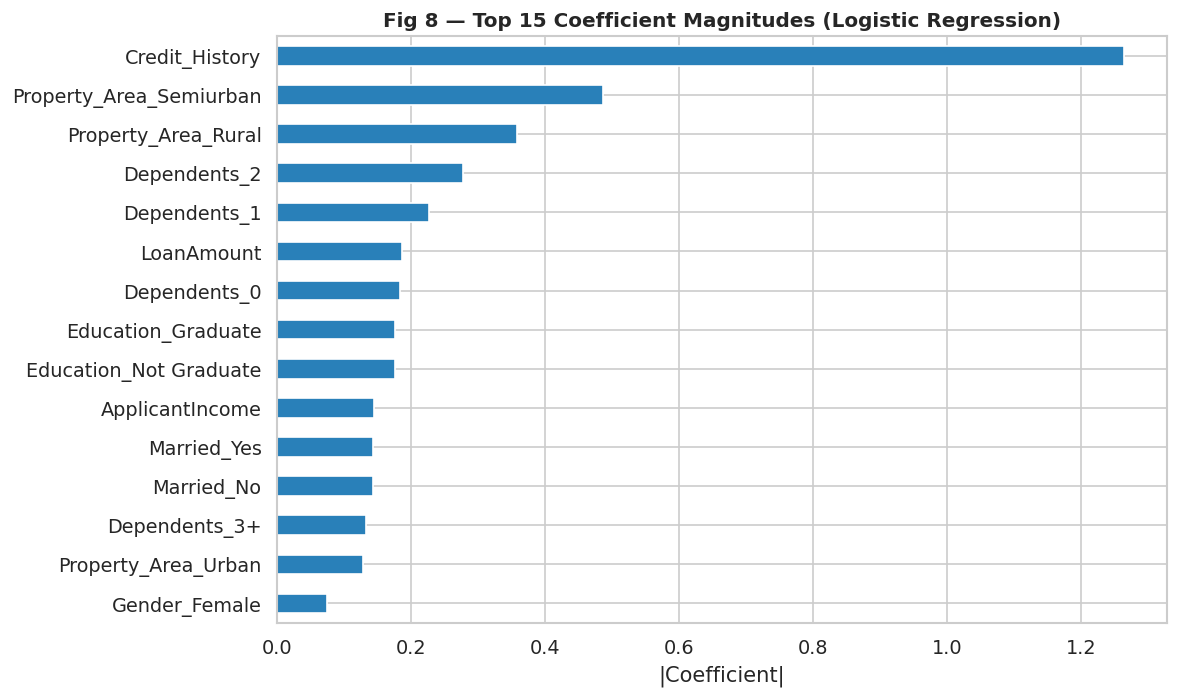

In [39]:
# Pick best model by ROC-AUC
best_name = max(results, key=lambda k: results[k]['roc_auc'] or 0)
best_model = results[best_name]['model']
print(f'Best model: {best_name} (AUC = {results[best_name]["roc_auc"]:.3f})')

# Get feature names from preprocessor
try:
    ohe_features = preprocessor.named_transformers_['cat']['encoder'].get_feature_names_out(cat_features).tolist()
except:
    ohe_features = []
all_feature_names = num_features + ohe_features

if hasattr(best_model, 'feature_importances_'):
    importances = best_model.feature_importances_
    fi_df = pd.Series(importances, index=all_feature_names[:len(importances)]).sort_values(ascending=False).head(15)

    fig, ax = plt.subplots(figsize=(10, 6))
    colors_fi = sns.color_palette('viridis', len(fi_df))
    fi_df[::-1].plot(kind='barh', ax=ax, color=colors_fi)
    ax.set_title(f'Fig 8 — Top 15 Feature Importances ({best_name})', fontsize=12)
    ax.set_xlabel('Importance')
    plt.tight_layout()
    plt.savefig('fig8_feature_importance.png', bbox_inches='tight')
    plt.show()
elif hasattr(best_model, 'coef_'):
    coefs = np.abs(best_model.coef_[0])
    fi_df = pd.Series(coefs, index=all_feature_names[:len(coefs)]).sort_values(ascending=False).head(15)
    fig, ax = plt.subplots(figsize=(10, 6))
    fi_df[::-1].plot(kind='barh', ax=ax, color='#2980B9')
    ax.set_title(f'Fig 8 — Top 15 Coefficient Magnitudes (Logistic Regression)', fontsize=12)
    ax.set_xlabel('|Coefficient|')
    plt.tight_layout()
    plt.savefig('fig8_feature_importance.png', bbox_inches='tight')
    plt.show()

## 🎯 Step 14 — Threshold Tuning (Precision-Recall Trade-off)

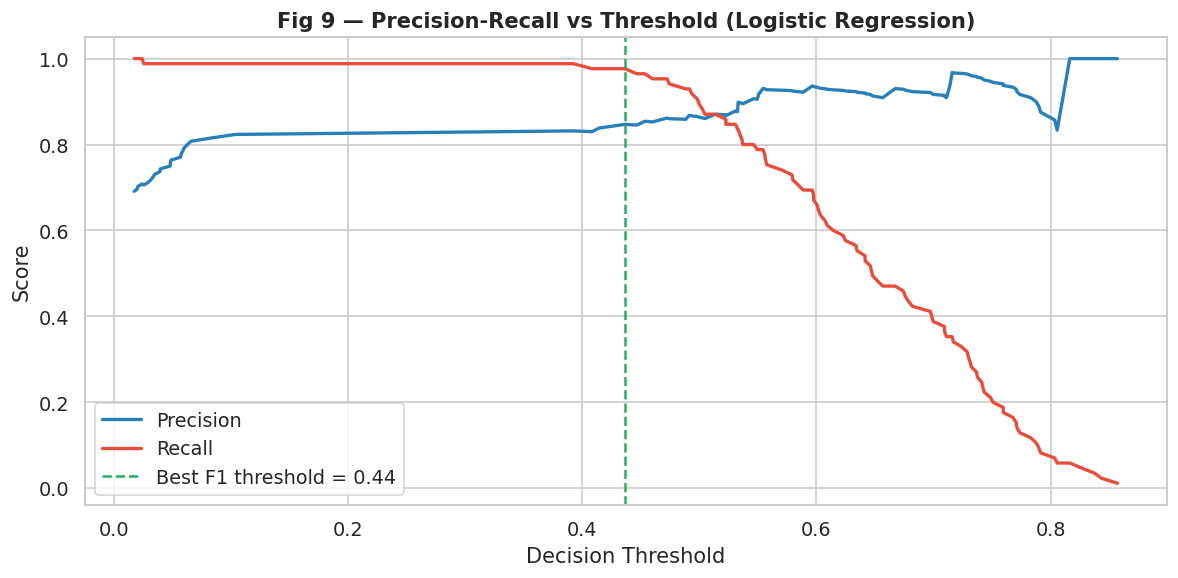


=== Optimal Threshold Analysis ===
Threshold for max F1  : 0.436
F1  @ optimal threshold : 0.907
Precision @ threshold   : 0.847
Recall    @ threshold   : 0.976


In [40]:
best_proba = results[best_name]['y_proba']
precisions, recalls, thresholds = precision_recall_curve(y_test, best_proba)

fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(thresholds, precisions[:-1], color='#2980B9', lw=2, label='Precision')
ax.plot(thresholds, recalls[:-1],    color='#E74C3C', lw=2, label='Recall')

# F1 at each threshold
f1_scores = 2 * (precisions[:-1] * recalls[:-1]) / (precisions[:-1] + recalls[:-1] + 1e-9)
best_thresh_idx = np.argmax(f1_scores)
best_thresh = thresholds[best_thresh_idx]
ax.axvline(best_thresh, color='#27AE60', linestyle='--', lw=1.5,
           label=f'Best F1 threshold = {best_thresh:.2f}')

ax.set_xlabel('Decision Threshold')
ax.set_ylabel('Score')
ax.set_title(f'Fig 9 — Precision-Recall vs Threshold ({best_name})')
ax.legend()
plt.tight_layout()
plt.savefig('fig9_threshold_tuning.png', bbox_inches='tight')
plt.show()

print(f'\n=== Optimal Threshold Analysis ===')
print(f'Threshold for max F1  : {best_thresh:.3f}')

y_pred_tuned = (best_proba >= best_thresh).astype(int)
print(f'F1  @ optimal threshold : {f1_score(y_test, y_pred_tuned):.3f}')
print(f'Precision @ threshold   : {precision_score(y_test, y_pred_tuned):.3f}')
print(f'Recall    @ threshold   : {recall_score(y_test, y_pred_tuned):.3f}')

## 📋 Step 15 — Final Summary & Business Interpretation

In [42]:
print('=' * 68)
print('         LOAN APPROVAL MODEL — FINAL PERFORMANCE SUMMARY')
print('=' * 68)
print(metrics_df.round(3).to_string())
print()
print(f'Best model (by ROC-AUC): {best_name}')
print(f'Recommended deployment threshold: {best_thresh:.2f}')
print()
print('=' * 68)
print('  BUSINESS INTERPRETATION')
print('=' * 68)
print(f'''
1. FALSE NEGATIVES (Approved applicants predicted as Rejected)
   → These are creditworthy customers the bank turns away.
   → Lower the threshold to reduce false negatives if revenue
     growth is the priority.

2. FALSE POSITIVES (Rejected applicants predicted as Approved)
   → These are risky borrowers who may default.
   → Raise the threshold to reduce false positives if risk
     management is the priority.

3. RECOMMENDED THRESHOLD: {best_thresh:.2f}
   → Balances both business risks at the optimal F1 score.
   → Adjust based on cost-of-default vs cost-of-missed-revenue.

4. SMOTE improved model recall on the minority class without
   leaking test-set information (applied only to training data).

5. TOP PREDICTORS: Applicant income, loan amount, credit history,
   and co-applicant income are typically the strongest signals.
''')
print('=' * 68)
print('Author: Shaik Yasmin | Alfido Tech Data Science Internship')

         LOAN APPROVAL MODEL — FINAL PERFORMANCE SUMMARY
                     Accuracy  Precision  Recall  F1-Score  ROC-AUC
Logistic Regression     0.821      0.862   0.882     0.872    0.876
Decision Tree           0.732      0.802   0.812     0.807    0.674
Random Forest           0.805      0.835   0.894     0.864    0.788
Gradient Boosting       0.764      0.833   0.824     0.828    0.773

Best model (by ROC-AUC): Logistic Regression
Recommended deployment threshold: 0.44

  BUSINESS INTERPRETATION

1. FALSE NEGATIVES (Approved applicants predicted as Rejected)
   → These are creditworthy customers the bank turns away.
   → Lower the threshold to reduce false negatives if revenue
     growth is the priority.

2. FALSE POSITIVES (Rejected applicants predicted as Approved)
   → These are risky borrowers who may default.
   → Raise the threshold to reduce false positives if risk
     management is the priority.

3. RECOMMENDED THRESHOLD: 0.44
   → Balances both business risks at the 